In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import shutil, os

path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
print("Đã tải về:", path)

# Copy toàn bộ file vào thư mục data/ trong project
dest = "data"
os.makedirs(dest, exist_ok=True)
for f in os.listdir(path):
    shutil.copy(os.path.join(path, f), dest)

print("Các file trong data/:", os.listdir(dest))

Đã tải về: C:\Users\NHUT HUY\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques
Các file trong data/: ['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']


# I. Định nghĩa vấn đề
----

## 1. Mục tiêu bài toán

Bộ dữ liệu gồm thông tin về các đặc điểm của nhà ở tại Ames, Iowa. Mục tiêu là phân tích 79 thuộc tính của ngôi nhà và xây dựng mô hình dự đoán giá bán (`SalePrice`). Cột `Id` chỉ là mã định danh, không dùng làm đặc trưng dự đoán.

## 2. Ý nghĩa 79 thuộc tính

| Thuộc tính | Ý nghĩa |
|---|---|
| `MSSubClass` | Mã phân loại loại hình nhà ở |
| `MSZoning` | Phân vùng sử dụng đất |
| `LotFrontage` | Chiều dài mặt tiền lô đất |
| `LotArea` | Diện tích lô đất |
| `Street` | Loại đường tiếp giáp |
| `Alley` | Loại hẻm tiếp giáp |
| `LotShape` | Hình dạng lô đất |
| `LandContour` | Địa hình lô đất |
| `Utilities` | Các tiện ích công cộng |
| `LotConfig` | Cấu hình/vị trí lô đất |
| `LandSlope` | Độ dốc của lô đất |
| `Neighborhood` | Khu vực lân cận |
| `Condition1` | Điều kiện vị trí gần nhà |
| `Condition2` | Điều kiện vị trí gần nhà thứ hai |
| `BldgType` | Loại công trình |
| `HouseStyle` | Kiểu kiến trúc ngôi nhà |
| `OverallQual` | Chất lượng tổng thể |
| `OverallCond` | Tình trạng tổng thể |
| `YearBuilt` | Năm xây dựng |
| `YearRemodAdd` | Năm sửa chữa hoặc cải tạo gần nhất |
| `RoofStyle` | Kiểu mái |
| `RoofMatl` | Vật liệu mái |
| `Exterior1st` | Vật liệu mặt ngoài chính |
| `Exterior2nd` | Vật liệu mặt ngoài phụ |
| `MasVnrType` | Loại vật liệu ốp tường trang trí |
| `MasVnrArea` | Diện tích vật liệu ốp tường |
| `ExterQual` | Chất lượng vật liệu bên ngoài |
| `ExterCond` | Tình trạng vật liệu bên ngoài |
| `Foundation` | Loại móng |
| `BsmtQual` | Chất lượng tầng hầm |
| `BsmtCond` | Tình trạng tầng hầm |
| `BsmtExposure` | Mức độ tiếp xúc với ánh sáng của tầng hầm |
| `BsmtFinType1` | Loại hoàn thiện tầng hầm phần 1 |
| `BsmtFinSF1` | Diện tích hoàn thiện tầng hầm phần 1 |
| `BsmtFinType2` | Loại hoàn thiện tầng hầm phần 2 |
| `BsmtFinSF2` | Diện tích hoàn thiện tầng hầm phần 2 |
| `BsmtUnfSF` | Diện tích tầng hầm chưa hoàn thiện |
| `TotalBsmtSF` | Tổng diện tích tầng hầm |
| `Heating` | Loại hệ thống sưởi |
| `HeatingQC` | Chất lượng hệ thống sưởi |
| `CentralAir` | Có hệ thống điều hòa trung tâm hay không |
| `Electrical` | Hệ thống điện |
| `1stFlrSF` | Diện tích tầng 1 |
| `2ndFlrSF` | Diện tích tầng 2 |
| `LowQualFinSF` | Diện tích hoàn thiện chất lượng thấp |
| `GrLivArea` | Diện tích sinh hoạt phía trên mặt đất |
| `BsmtFullBath` | Số phòng tắm đầy đủ ở tầng hầm |
| `BsmtHalfBath` | Số phòng tắm một phần ở tầng hầm |
| `FullBath` | Số phòng tắm đầy đủ phía trên mặt đất |
| `HalfBath` | Số phòng tắm một phần phía trên mặt đất |
| `BedroomAbvGr` | Số phòng ngủ phía trên mặt đất |
| `KitchenAbvGr` | Số bếp phía trên mặt đất |
| `KitchenQual` | Chất lượng nhà bếp |
| `TotRmsAbvGrd` | Tổng số phòng phía trên mặt đất |
| `Functional` | Mức độ tiện dụng của ngôi nhà |
| `Fireplaces` | Số lượng lò sưởi |
| `FireplaceQu` | Chất lượng lò sưởi |
| `GarageType` | Loại nhà để xe |
| `GarageYrBlt` | Năm xây dựng nhà để xe |
| `GarageFinish` | Mức độ hoàn thiện nhà để xe |
| `GarageCars` | Sức chứa nhà để xe theo số ô tô |
| `GarageArea` | Diện tích nhà để xe |
| `GarageQual` | Chất lượng nhà để xe |
| `GarageCond` | Tình trạng nhà để xe |
| `PavedDrive` | Tình trạng đường vào nhà để xe |
| `WoodDeckSF` | Diện tích sàn gỗ ngoài trời |
| `OpenPorchSF` | Diện tích hiên mở |
| `EnclosedPorch` | Diện tích hiên có vách bao quanh |
| `3SsnPorch` | Diện tích hiên sử dụng được 3 mùa |
| `ScreenPorch` | Diện tích hiên có lưới chắn |
| `PoolArea` | Diện tích hồ bơi |
| `PoolQC` | Chất lượng hồ bơi |
| `Fence` | Loại hàng rào |
| `MiscFeature` | Các đặc điểm bổ sung khác |
| `MiscVal` | Giá trị của đặc điểm bổ sung |
| `MoSold` | Tháng bán nhà |
| `YrSold` | Năm bán nhà |
| `SaleType` | Loại hình giao dịch bán |

Trong đó, các thuộc tính số mô tả diện tích, số lượng hoặc thời gian; các thuộc tính phân loại mô tả loại hình, chất lượng và tình trạng của ngôi nhà. Đây là những yếu tố có thể ảnh hưởng đến giá bán `SalePrice`.

# II. EDA - Phân tích khám phá dữ liệu
---
## 0. Import thư viện
---

In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

## 1. Tải dữ liệu
---

In [4]:
train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')

print("Train Data Shape: ", train_data.shape)
print("Test Data Shape: ", test_data.shape)

Train Data Shape:  (1460, 81)
Test Data Shape:  (1459, 80)


### Phân tích skewness và phân phối của biến mục tiêu

Biến mục tiêu `SalePrice` cần được kiểm tra trước khi xây dựng mô hình. Histogram giúp quan sát hình dạng phân phối, còn skewness cho biết mức độ lệch của dữ liệu. Ngoài ra, ta xem xét các biến số có tương quan mạnh nhất với `SalePrice` để hiểu những yếu tố có thể ảnh hưởng đến giá nhà.

Skewness: 1.8828757597682129


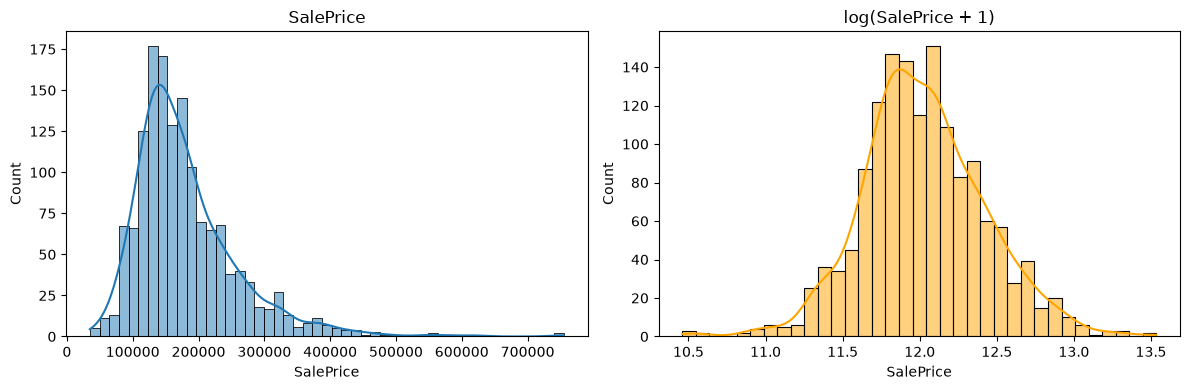

In [118]:
y = train_data['SalePrice']
print('Skewness:', y.skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, kde=True, ax=axes[0])
sns.histplot(np.log1p(y), kde=True, ax=axes[1], color='orange')
axes[0].set_title('SalePrice')
axes[1].set_title('log(SalePrice + 1)')
plt.tight_layout()
plt.show()

- Tập train bao gồm 81 cột (79 thuộc tính + id, target SalePrice) và 1480 dòng dữ liệu.
- Tập test bao gồm 80 cột (79 thuộc tính + id) và 1459 dòng dữ liệu.

### Thông tin bộ dữ liệu trên TRAIN

In [108]:
print(train_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [109]:
print(test_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

## 2. Kiểm tra giá trị NULL
---

### Train Data

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


<Axes: >

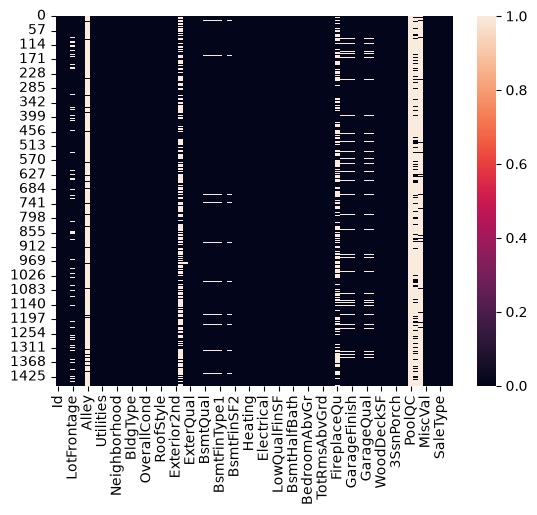

In [110]:
print(train_data.isnull().sum())

sns.heatmap(train_data.isnull())

### Test Data

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

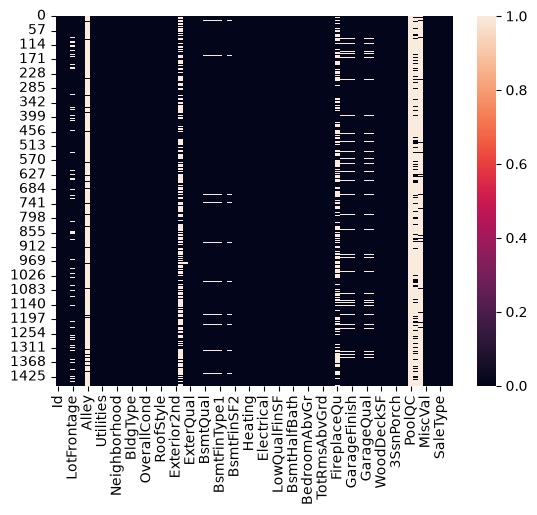

In [111]:
print(test_data.isnull().sum())

sns.heatmap(train_data.isnull())

- Nhận thấy bộ dữ liệu có nhiều giá trị thiếu ở một số thuộc tính, đặc biệt là các thuộc tính liên quan đến tầng hầm, nhà để xe, lò sưởi và vật liệu trang trí.
- Giá trị thiếu không nhất thiết là lỗi nhập liệu. Trong nhiều trường hợp, giá trị thiếu thể hiện rằng ngôi nhà không có thành phần tương ứng, chẳng hạn không có tầng hầm, nhà để xe hoặc lò sưởi.
- Tuy nhiên, để các mô hình học máy có thể xử lý dữ liệu ổn định, cần thay thế các giá trị `NULL` trước khi huấn luyện và dự đoán.

## 3. Xử lý dữ liệu NULL
---
### Train Data



In [5]:
cat_col_train = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                 'GarageQual', 'GarageCond','Electrical']

ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for column in cat_col_train:
    train_data[column] = train_data[column].fillna(train_data[column].mode()[0])

for column in ncat_col_train:
    train_data[column] = train_data[column].fillna(train_data[column].mean())


### Test Data

In [6]:
cat_col_test = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st',
                'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']

ncat_col_test = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars',
                 'GarageArea']

for column in cat_col_test:
    test_data[column] = test_data[column].fillna(test_data[column].mode()[0])

for column in ncat_col_test:
    test_data[column] = test_data[column].fillna(test_data[column].mean())

### Loại bỏ các cột thừa

<Axes: >

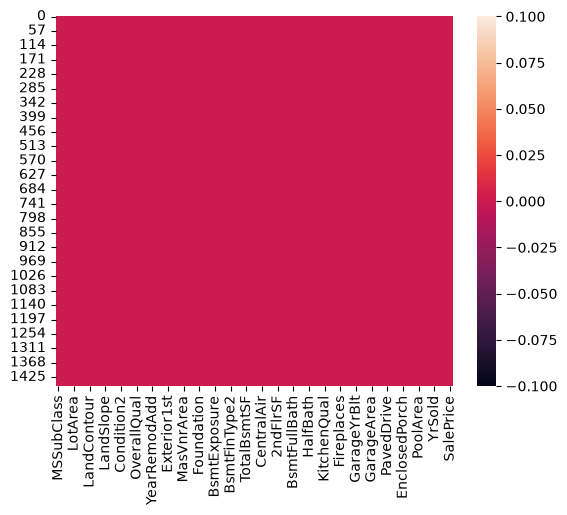

In [7]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

train_data.drop(columns=to_drop, inplace=True, errors='ignore')
test_data.drop(columns=to_drop, inplace=True, errors='ignore')

sns.heatmap(train_data.isnull())

### Nhận xét

- Với các thuộc tính phân loại, sử dụng **mode** (giá trị xuất hiện nhiều nhất) để thay thế giá trị thiếu. Cách này giúp giữ lại một nhãn hợp lệ và hạn chế tạo ra một nhóm phân loại mới không có ý nghĩa.
- Với các thuộc tính số, sử dụng **mean** (giá trị trung bình) để điền giá trị thiếu. Đây là cách đơn giản, phù hợp với mục tiêu giữ nguyên quy mô chung của dữ liệu.
- Tập train và tập test được xử lý theo cùng một nguyên tắc để bảo đảm dữ liệu đầu vào của mô hình có cấu trúc nhất quán.
- Sau bước này, cần kiểm tra lại số lượng giá trị thiếu. Nếu vẫn còn `NULL`, đó có thể là những cột chưa được đưa vào danh sách xử lý hoặc có kiểu dữ liệu cần xem xét riêng.
- Việc điền giá trị trung bình và mode giúp mô hình chạy được, nhưng có thể làm giảm một phần thông tin về việc một ngôi nhà có hay không có tiện ích. Ở các bước nâng cao, có thể cân nhắc mã hóa riêng trạng thái không có tiện ích hoặc dùng phương pháp điền giá trị phù hợp hơn với từng thuộc tính.

## 4. Xử lý dữ liệu trước khi đưa vào mô hình
---

**Về vấn đề xử lý outlier có giá trị cao hay thấp có nên hay không?**:

Trong dữ liệu nhà đất, các giá trị cực lớn như nhà có diện tích rất rộng hoặc giá rất cao có thể là dữ liệu thật, không phải noise. Xóa chúng có thể làm mất thông tin quan trọng.

In [8]:
def cat_onehot_encoding(data, categorical_columns):
    encoded_data = data.copy()
    existing_columns = [
        column for column in categorical_columns
        if column in encoded_data.columns
    ]

    for column in existing_columns:
        encoded_data[column] = encoded_data[column].fillna(
            encoded_data[column].mode()[0]
        )

    encoded_data = pd.get_dummies(
        encoded_data,
        columns=existing_columns,
        drop_first=True,
        dtype=int
    )

    return encoded_data

# Tách biến mục tiêu trước khi ghép dữ liệu
if 'SalePrice' in train_data.columns:
    sale_price = train_data['SalePrice'].copy()
    train_features = train_data.drop(columns=['SalePrice'])
else:
    sale_price = None
    train_features = train_data.copy()

# Ghép tạm thời train và test để mã hóa các cột phân loại thống nhất
train_rows = len(train_features)
final_df = pd.concat([train_features, test_data], axis=0, ignore_index=True)

print("Kích thước dữ liệu sau khi ghép:", final_df.shape)

all_cat_col = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
    'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PavedDrive', 'SaleType', 'SaleCondition'
]

final_df = cat_onehot_encoding(final_df, all_cat_col)

# Tách lại hai tập dữ liệu sau khi mã hóa
train_data = final_df.iloc[:train_rows].copy()
test_data = final_df.iloc[train_rows:].copy()

print("Train Shape:", train_data.shape)
print("Test Shape:", test_data.shape)
print("Số giá trị NULL còn lại:", final_df.isnull().sum().sum())

Kích thước dữ liệu sau khi ghép: (2919, 75)
Train Shape: (1460, 235)
Test Shape: (1459, 235)
Số giá trị NULL còn lại: 0


## 5. Định nghĩa các mô hình
---

### 5.1. XGBoot
---

In [9]:
import xgboost as xgb

X = train_data
X_test = test_data
y = np.log1p(sale_price)

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X, y)
print('Đã huấn luyện XGBoost')

Đã huấn luyện XGBoost


In [10]:
from sklearn.model_selection import KFold, RandomizedSearchCV

param_grid = {
    'n_estimators': [500, 900, 1500],
    'max_depth': [2, 3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'min_child_weight': [1, 2, 4],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 5, 10]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X, y)
print('Tham số tốt nhất:', search.best_params_)
print('RMSE tốt nhất:', -search.best_score_)
xgb_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tham số tốt nhất: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 900, 'min_child_weight': 4, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
RMSE tốt nhất: 0.12984771065041995


#### Lưu mô hình và dự đoán

Sau khi tuning, sử dụng mô hình XGBoost tốt nhất để dự đoán giá nhà trên tập test. Vì mô hình được huấn luyện với `log1p(SalePrice)`, cần dùng `expm1()` để đưa kết quả về đơn vị giá ban đầu.

In [31]:
import pickle

with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

pred_xgb_log = xgb_model.predict(X_test)
pred_xgb = np.expm1(pred_xgb_log)

submission = pd.read_csv('data/sample_submission.csv')
submission['SalePrice'] = pred_xgb
submission.to_csv('submission_xgb.csv', index=False)

print('Kích thước dự đoán:', pred_xgb.shape)
print('Đã lưu: xgb_model.pkl và submission_xgb.csv')

Kích thước dự đoán: (1459,)
Đã lưu: xgb_model.pkl và submission_xgb.csv


### 5.2. Decision Tree
---

Decision Tree được dùng làm mô hình cơ sở để so sánh với XGBoost.

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor

param_dt = {
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

search_dt = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=param_dt,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
search_dt.fit(X, y)

print('Decision Tree tham số tốt nhất:', search_dt.best_params_)
print('Decision Tree RMSE tốt nhất:', -search_dt.best_score_)
dt_model = search_dt.best_estimator_

Decision Tree tham số tốt nhất: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 8}
Decision Tree RMSE tốt nhất: 0.19159546417049256


#### Lưu mô hình và dự đoán

In [30]:
pred_dt = np.expm1(dt_model.predict(X_test))
submission_dt = pd.read_csv('data/sample_submission.csv')
submission_dt['SalePrice'] = pred_dt
submission_dt.to_csv('submission_dt.csv', index=False)

print('Decision Tree prediction:', pred_dt.shape)

Decision Tree prediction: (1459,)


### 5.3 Artificial Neural Network
---

ANN cần chuẩn hóa dữ liệu đầu vào. Ở đây dùng `MLPRegressor` của scikit-learn để dự đoán biến mục tiêu trong không gian log.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

param_nn = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.0005, 0.001, 0.01]
}

search_nn = RandomizedSearchCV(
    MLPRegressor(
        solver='adam',
        max_iter=500,
        early_stopping=True,
        random_state=42
    ),
    param_distributions=param_nn,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
search_nn.fit(X_scaled, y)

print('ANN tham số tốt nhất:', search_nn.best_params_)
print('ANN RMSE tốt nhất:', -search_nn.best_score_)
nn_model = search_nn.best_estimator_

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by atleast ``tol`` for ``n_iter_no_change`` consecutive epochs.Only effective when solver='sgd' or 'adam'.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when sol

#### Lưu mô hình và dự đoán

In [27]:
pred_nn = np.expm1(nn_model.predict(X_test_scaled))
submission_nn = pd.read_csv('data/sample_submission.csv')
submission_nn['SalePrice'] = pred_nn
submission_nn.to_csv('submission_nn.csv', index=False)

print('ANN prediction:', pred_nn.shape)

ANN prediction: (1459,)


### 5.4. Random Forest
---

Random Forest kết hợp nhiều Decision Tree, thường ổn định hơn một cây đơn và được dùng để so sánh với XGBoost.

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

param_rf = {
    'n_estimators': [300, 500, 800],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [0.6, 0.8, 1.0]
}

search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_rf,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
search_rf.fit(X, y)

print('Random Forest tham số tốt nhất:', search_rf.best_params_)
print('Random Forest RMSE tốt nhất:', -search_rf.best_score_)
rf_model = search_rf.best_estimator_

Random Forest tham số tốt nhất: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.6, 'max_depth': None}
Random Forest RMSE tốt nhất: 0.14090258719253965


#### Lưu mô hình và dự đoán

In [29]:
pred_rf = np.expm1(rf_model.predict(X_test))
submission_rf = pd.read_csv('data/sample_submission.csv')
submission_rf['SalePrice'] = pred_rf
submission_rf.to_csv('submission_rf.csv', index=False)

print('Random Forest prediction:', pred_rf.shape)

Random Forest prediction: (1459,)
